In this notebook we will implement a neural network that can learn the parameters of a linear optimization problem. 

# Part 1: data obtaining and preprocessing

In [1]:
import numpy as np
import deep_inv_opt as io
import deep_inv_opt.plot as iop
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

from diffcp import SolverError
import torch
import cvxpy as cp
from cvxpylayers.torch import CvxpyLayer
import contextlib
import io as io2


import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.max_open_warning'] = 0  # Let the plots flow!
%matplotlib inline

In [2]:
u_train = io.tensor(np.linspace(-1.5, 1.5, 1024).reshape((-1, 1)))
u_train

tensor([[-1.5000],
        [-1.4971],
        [-1.4941],
        ...,
        [ 1.4941],
        [ 1.4971],
        [ 1.5000]], dtype=torch.float64)

In [3]:
u_train, u_val = train_test_split(u_train, test_size=0.2, random_state=42)

u_train, u_test = train_test_split(u_train, test_size=0.15, random_state=42)

In [4]:
u_train

tensor([[ 1.6276e-01],
        [ 8.9589e-01],
        [ 1.4531e+00],
        [ 5.6745e-01],
        [-2.6246e-01],
        [ 1.3768e+00],
        [-1.2757e-01],
        [ 9.8094e-01],
        [ 9.8680e-01],
        [ 1.1862e+00],
        [ 5.1320e-02],
        [ 9.5748e-01],
        [-5.5865e-01],
        [ 6.7302e-01],
        [-2.8006e-01],
        [ 8.7243e-01],
        [ 1.4501e+00],
        [-9.0469e-01],
        [ 8.5777e-01],
        [ 3.5630e-01],
        [-1.3328e+00],
        [ 1.5103e-01],
        [-1.4062e+00],
        [ 1.3094e+00],
        [-1.6129e-02],
        [-7.6393e-01],
        [-3.8270e-01],
        [ 3.0645e-01],
        [ 5.7185e-02],
        [ 1.1774e+00],
        [ 8.4311e-01],
        [-3.6217e-01],
        [-6.9648e-01],
        [ 7.7859e-01],
        [-6.6716e-01],
        [ 2.9472e-01],
        [-2.2141e-01],
        [ 7.0235e-01],
        [ 9.3695e-01],
        [ 7.1994e-01],
        [-9.1056e-01],
        [ 5.4985e-01],
        [-1.4223e-01],
        [ 6

In [5]:
u_val

tensor([[ 0.0396],
        [-0.4531],
        [-0.1979],
        [-1.4091],
        [ 0.3123],
        [ 0.2214],
        [-0.1891],
        [ 0.6525],
        [-1.2771],
        [ 0.5968],
        [-0.4150],
        [-1.2947],
        [ 0.4853],
        [-1.2038],
        [ 0.3211],
        [ 0.4150],
        [-0.6789],
        [-0.2537],
        [-0.3152],
        [ 0.6965],
        [-1.2185],
        [ 1.1452],
        [-0.7346],
        [-0.5850],
        [ 0.0543],
        [ 0.5411],
        [-0.4384],
        [-0.6525],
        [ 1.0982],
        [ 1.4296],
        [ 0.2918],
        [ 0.5381],
        [ 1.4589],
        [-0.5411],
        [-0.2947],
        [-0.6613],
        [-0.8754],
        [ 0.3475],
        [-0.2331],
        [-0.9164],
        [ 0.3710],
        [ 1.3270],
        [ 0.9340],
        [ 0.2331],
        [-0.1012],
        [-0.3446],
        [ 1.2449],
        [-0.7845],
        [ 0.2977],
        [-0.6496],
        [ 1.1276],
        [ 0.3856],
        [-1.

In [6]:
u_test

tensor([[ 1.2361],
        [ 1.2214],
        [-1.1188],
        [ 1.3974],
        [-0.3534],
        [-1.0806],
        [-0.8431],
        [ 0.1481],
        [-0.9927],
        [-0.6408],
        [ 0.0455],
        [-1.2801],
        [-0.2742],
        [ 0.9692],
        [-0.4501],
        [ 0.4091],
        [-1.3651],
        [-0.2830],
        [-0.9545],
        [ 0.6760],
        [-0.2566],
        [-1.0396],
        [ 0.2155],
        [-0.4853],
        [-0.9575],
        [ 0.3680],
        [ 0.1921],
        [-0.2595],
        [-0.6144],
        [ 0.6466],
        [ 0.0015],
        [ 0.7522],
        [ 0.5616],
        [ 0.0630],
        [ 1.2625],
        [ 0.8050],
        [-0.5176],
        [-0.9780],
        [-1.0337],
        [-1.4443],
        [-0.1481],
        [ 0.4443],
        [-1.3798],
        [-1.3123],
        [ 1.4648],
        [-0.7199],
        [ 0.2038],
        [ 0.2097],
        [-0.6818],
        [ 0.2742],
        [ 0.7874],
        [ 1.1041],
        [-0.

Now we generate the data from the real problem.

In [7]:
class ExamplePLP(io.ParametricLP):
    # Generate an LP from a given feature vector u and weight vector w.
    def generate(self, u, w):
        c = [[torch.cos(w[0] + w[1]*u)],
             [torch.sin(w[0] + w[1]*u)]]

        A_ub = [[-1.0,  0.0],
                [ 0.0, -1.0],
                [ w[0], 1 + w[1]*u/3]]

        b_ub = [[ 0.2*w[0]*u],
                [-0.2*w[1]*u],
                [ w[0] + 0.1*u]]
        
        return c, A_ub, b_ub, None, None

In [8]:
plp_true = ExamplePLP(weights=[1.0, 1.0])

# Generate training targets by solve the true PLP.
x_train = torch.cat([io.linprog(*plp_true(ui)).detach().t() for ui in u_train])
# torch.save(x_train, "x_train.pt")

x_val = torch.cat([io.linprog(*plp_true(ui)).detach().t() for ui in u_val])
# torch.save(x_val, "x_val.pt")

x_test = torch.cat([io.linprog(*plp_true(ui)).detach().t() for ui in u_test])
# torch.save(x_test, "x_test.pt")

In [9]:
# x_val = torch.load("x_val.pt")
x_val

tensor([[-0.0079,  0.0079],
        [ 0.0906, -0.0906],
        [ 0.0396, -0.0396],
        [ 0.2818,  1.0886],
        [-0.0624,  0.0625],
        [-0.0443,  0.0443],
        [ 0.0378, -0.0378],
        [ 0.9063,  0.1305],
        [ 0.2554,  1.0741],
        [ 0.9164,  0.1194],
        [ 0.0830, -0.0830],
        [ 0.2589,  1.0759],
        [-0.0970,  0.0971],
        [ 0.2408,  1.0670],
        [-0.0642,  0.0642],
        [-0.0830,  0.0830],
        [ 0.1358, -0.1358],
        [ 0.0507, -0.0507],
        [ 0.0631, -0.0630],
        [ 0.8980,  0.1393],
        [ 0.2437,  1.0684],
        [ 0.7980,  0.2290],
        [ 0.1469, -0.1469],
        [ 0.1170, -0.1170],
        [-0.0108,  0.0109],
        [-0.1080,  0.1082],
        [ 0.0877, -0.0877],
        [ 0.1305, -0.1305],
        [ 0.8098,  0.2197],
        [ 0.7208,  0.2859],
        [-0.0583,  0.0584],
        [-0.1075,  0.1076],
        [ 0.7122,  0.2918],
        [ 0.1082, -0.1082],
        [ 0.0589, -0.0589],
        [ 0.1323, -0

In [10]:
# x_train = torch.load("x_train.pt")
x_train

tensor([[-0.0325,  0.0326],
        [ 0.8569,  0.1792],
        [ 0.7139,  0.2906],
        ...,
        [-0.1000,  0.1000],
        [ 0.1997, -0.1958],
        [-0.0542,  0.0543]], dtype=torch.float64)

In [11]:
# x_test = torch.load("x_test.pt")
x_test

tensor([[ 7.7452e-01,  2.4722e-01],
        [ 7.7839e-01,  2.4428e-01],
        [ 2.2376e-01,  1.0594e+00],
        [ 7.3008e-01,  2.7948e-01],
        [ 7.0679e-02, -7.0669e-02],
        [ 2.1613e-01,  1.0563e+00],
        [ 1.6863e-01, -1.6859e-01],
        [-2.9607e-02,  2.9624e-02],
        [ 1.9854e-01, -1.9775e-01],
        [ 1.2816e-01, -1.2814e-01],
        [-9.0834e-03,  9.0953e-03],
        [ 2.5602e-01,  1.0744e+00],
        [ 5.4843e-02, -5.4834e-02],
        [ 8.4044e-01,  1.9385e-01],
        [ 9.0033e-02, -9.0023e-02],
        [-8.1787e-02,  8.1823e-02],
        [ 2.7302e-01,  1.0835e+00],
        [ 5.6603e-02, -5.6593e-02],
        [ 1.9091e-01, -1.9080e-01],
        [ 9.0191e-01,  1.3519e-01],
        [ 5.1324e-02, -5.1315e-02],
        [ 2.0792e-01,  1.0529e+00],
        [-4.3094e-02,  4.3114e-02],
        [ 9.7071e-02, -9.7060e-02],
        [ 1.9150e-01, -1.9138e-01],
        [-7.3582e-02,  7.3612e-02],
        [-3.8403e-02,  3.8422e-02],
        [ 5.1911e-02, -5.190

# Part 2: model definition and training

In [12]:
# Check if we are using a GPU or CPU
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [13]:
learning_rate = 1e-3
batch_size = 16

In [14]:
# Dataset and DataLoader definition
class UDataset(Dataset):
    def __init__(self, data, targets):
        self.data = data.clone().to(dtype=torch.float32) 
        self.targets = targets.clone().to(dtype=torch.float32)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.targets[idx]

# Dataset (u, x)
dataset = UDataset(u_train, x_train)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [15]:
val_dataset = UDataset(u_val, x_val)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)

test_dataset = UDataset(u_test, x_test)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

In [16]:
def gradient_descent_solver(c, A, b, lr=0.01, max_iter=1000, tol=1e-6, M=1000.0):
    """
    Solve a linear optimization problem with constraints using gradient descent.

    Parameters:
    - c: Cost vector (n,)
    - A: Constraint matrix (m, n)
    - b: Constraint vector (m,)
    - lr: Learning rate
    - max_iter: Maximum number of iterations
    - tol: Convergence tolerance

    Returns:
    - x: Optimal solution found
    """
    n = c.shape[0]
    x = torch.zeros(n, dtype=c.dtype, requires_grad=True)
    optimizer = torch.optim.SGD([x], lr=lr)

    for _ in range(max_iter):
        optimizer.zero_grad()
        objective = torch.dot(c, x) + M * torch.sum(torch.relu(A @ x - b)) # relu(x) = max(0, x)
        objective.backward(retain_graph=True)
        optimizer.step()

        if torch.norm(x.grad) < tol:
            break
    return x

def newton_solver(c, A, b, max_iter=100, tol=1e-6, M=1000.0):
    """
    Solve a linear optimization problem with constraints using the Newton method.

    Parameters:
    - c: Cost vector (n,)
    - A: Constraint matrix (m, n)
    - b: Constraint vector (m,)
    - max_iter: Maximum number of iterations
    - tol: Convergence tolerance

    Returns:
    - x: Optimal solution found
    """
    n = c.shape[0]
    x = torch.zeros(n, dtype=c.dtype, requires_grad=True)
    
    for _ in range(max_iter):
        loss = torch.dot(c, x) + M * torch.sum(torch.relu(A @ x - b))

        # Gradient and Hessian
        grad = torch.autograd.grad(loss, x, create_graph=True)[0]
        hess = torch.autograd.functional.hessian(lambda y: torch.dot(c, y) + M * torch.sum(torch.relu(A @ y - b)), x)

        # Newton step: Δx = -H⁻¹ * grad
        try:
            delta_x = torch.linalg.solve(hess, -grad)
        except RuntimeError:
            break  # Break if the Hessian is singular

        # Actualize x
        x = x + delta_x

        # Break if converged
        if torch.norm(delta_x) < tol:
            break

    return x


In [17]:
def solver(c_, A_, b_):
    try:
        M = 1000.0
        m, n = A_.shape

        A = cp.Parameter((m, n))
        b = cp.Parameter(m)
        c = cp.Parameter(n)
        x = cp.Variable(n)

        obj = cp.Minimize(c.T @ x + M * cp.sum(cp.pos(A @ x - b))) # cp.pos = max(0, x)

        cons = [0 * x >= 0]

        prob = cp.Problem(obj, cons)
        layer = CvxpyLayer(prob, parameters=[c, A, b], variables=[x])

        with io2.StringIO() as buf, contextlib.redirect_stdout(buf):
            solution, = layer(c_, A_, b_)
        return solution

    except SolverError:
        return newton_solver(c_, A_, b_)
    

In [18]:
# Define the model
class ParametricLPNet(nn.Module):
    def __init__(self):
        super(ParametricLPNet, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(1, 8),
            nn.ReLU(),
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, 8)  # c (2), A (4), b (2)
        )

    def forward(self, u):
        output = self.fc(u)        
        c = output[:, 0:2]
        A = output[:, 2:6].reshape(-1, 2, 2)
        b = output[:, 6:8]
        return torch.stack(list(map(solver, c, A, b)))

In [19]:
loss_fn = nn.MSELoss()

In [20]:
model = ParametricLPNet()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
# optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate) # elegir una de las dos

In [21]:
model

ParametricLPNet(
  (fc): Sequential(
    (0): Linear(in_features=1, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=8, bias=True)
  )
)

In [22]:
# Initialize the weights of the model
def initialize_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, nonlinearity='leaky_relu') # inicializamos los pesos de la red con Kaiming
        nn.init.zeros_(m.bias) # inicializamos los bias a 0

# initialize_weights(model)


# We load the trained model weights
model.load_state_dict(torch.load("model_weights.pth"))

<All keys matched successfully>

In [23]:
def near(rs, x_batch, tol=1e-3):
    '''
    rs: Tensor containing the solutions of the LPs  
    x_batch: Tensor containing the desired solutions of the LPs  
    tol: Tolerance to consider two vectors as equal  

    This function calculates the number of LP solutions that are within a distance  
    less than tol from the desired solutions.
    '''
    d = torch.sum((rs - x_batch) ** 2, dim=1)
    return torch.sum(d < tol).item()

In [24]:
tol = 0.1

def train_loop(dataloader, model, loss_fn, optimizer):
    model.train()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    loss_media = 0.0
    accuracy = 0.0
    batch_size = dataloader.batch_size
    for batch, (u_batch, x_batch) in enumerate(dataloader):

        rs = model(u_batch)
        loss = loss_fn(rs, x_batch)

        # Backpropagation and optimization
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 8 == 0:
            loss = loss.item()
            current = batch * batch_size + batch_size
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")
            
        loss_media += loss
        accuracy += near(rs, x_batch, tol)

    return loss_media / num_batches, accuracy / size

In [25]:
def val_loop(dataloader, model, loss_fn):
    model.eval()
    size=len(dataloader.dataset)
    num_batches = len(dataloader)
    val_loss, correct = 0, 0

    for u_batch, x_batch in dataloader:
        rs = model(u_batch)
        val_loss += loss_fn(rs, x_batch).item()
        correct += near(rs, x_batch, tol) # correct is the number of LP solutions that are within a distance less than tol from the desired solutions.
    val_loss /= num_batches
    correct /= size
    print(f"Validation Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {val_loss:>8f} \n\n")
    return val_loss, correct

In [26]:
val_acc = []
train_acc = []

train_acc = torch.load("train_acc.pth")
val_acc = torch.load("val_acc.pth")

In [27]:
# Entrenamiento
epochs = 5

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    loss, accuracy = train_loop(dataloader, model, loss_fn, optimizer)
    train_acc.append(accuracy)
    print(f"\nTraining Error: \n Accuracy: {(100*accuracy):>0.1f}%, Avg loss: {loss:>8f} \n")
    
    val_loss, accuracy_val = val_loop(val_dataloader, model, loss_fn)
    val_acc.append(accuracy_val)

print("Done!")

Epoch 1
-------------------------------
loss: 0.036931  [   16/  696]
loss: 0.018801  [  144/  696]
loss: 0.024885  [  272/  696]
loss: 0.021457  [  400/  696]
loss: 0.027423  [  528/  696]
loss: 0.040365  [  656/  696]

Training Error: 
 Accuracy: 83.6%, Avg loss: 0.028657 

Validation Error: 
 Accuracy: 92.2%, Avg loss: 0.014650 


Epoch 2
-------------------------------
loss: 0.016424  [   16/  696]
loss: 0.015347  [  144/  696]
loss: 0.019908  [  272/  696]
loss: 0.002344  [  400/  696]
loss: 0.011134  [  528/  696]
loss: 0.006372  [  656/  696]

Training Error: 
 Accuracy: 88.8%, Avg loss: 0.016819 

Validation Error: 
 Accuracy: 94.6%, Avg loss: 0.010725 


Epoch 3
-------------------------------
loss: 0.023304  [   16/  696]
loss: 0.024305  [  144/  696]
loss: 0.026980  [  272/  696]
loss: 0.005020  [  400/  696]
loss: 0.015217  [  528/  696]
loss: 0.009081  [  656/  696]

Training Error: 
 Accuracy: 91.5%, Avg loss: 0.013807 

Validation Error: 
 Accuracy: 95.1%, Avg loss: 0.00

/home/eca/miniconda3/lib/python3.12/site-packages/diffcp/cone_program.py:348: UserWarning: Solved/Inaccurate.
  warnings.warn("Solved/Inaccurate.")


loss: 0.057188  [  528/  696]
loss: 0.051494  [  656/  696]

Training Error: 
 Accuracy: 87.5%, Avg loss: 30470784.000000 

Validation Error: 
 Accuracy: 76.6%, Avg loss: 0.053110 


Done!


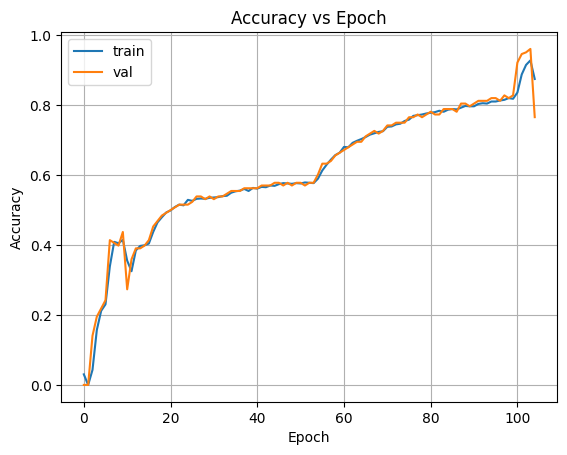

In [28]:
plt.figure()
plt.plot(train_acc, label="train")
plt.plot(val_acc, label="val")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.grid()
plt.show()

In [29]:
# torch.save(model.state_dict(), "model_weights.pth")

In [30]:
# save the accuracy 
# torch.save(train_acc, "train_acc.pth")
# torch.save(val_acc, "val_acc.pth")

## Evaluation of the model on the test set

In [31]:
model.eval()

ParametricLPNet(
  (fc): Sequential(
    (0): Linear(in_features=1, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=8, bias=True)
  )
)

In [32]:
u = torch.tensor([[0.25]], dtype=torch.float64)
x = torch.cat([io.linprog(*plp_true(ui)).detach().t() for ui in u])
u,x

(tensor([[0.2500]], dtype=torch.float64),
 tensor([[-0.0500,  0.0500]], dtype=torch.float64))

In [33]:
x_pred = model(torch.tensor([[0.25]]))
x_pred

tensor([[ 0.0227, -0.0704]], grad_fn=<StackBackward0>)

In [34]:
x, x_pred, torch.norm(x - x_pred)

(tensor([[-0.0500,  0.0500]], dtype=torch.float64),
 tensor([[ 0.0227, -0.0704]], grad_fn=<StackBackward0>),
 tensor(0.1406, dtype=torch.float64, grad_fn=<LinalgVectorNormBackward0>))

In [35]:
val_loop(test_dataloader, model, loss_fn)

Validation Error: 
 Accuracy: 76.4%, Avg loss: 0.055548 




(0.055548058124259114, 0.7642276422764228)